# Multi-Class Classification  7-Class Attack Classification

In this notebook, I implement an optimized pipeline for classifying 7 different attack types from the CICIoT2023 dataset.

### Pipeline Overview
1. **Data Loading and Preparation**: Loading the parquet files and cleaning missing/infinite values.
2. **Filtering and Encoding**: Isolating attack traffic and mapping labels to 0-6.
3. **Robust Scaling**: Utilizing RobustScaler to better handle extreme outliers common in network traffic.
4. **Feature Selection**: Training RF and ExtraTrees to extract the Top 30 most impactful features.
5. **Custom Sample Weights**: Applying a 1.5x boost to minority classes to force the models to learn their patterns.
6. **Baselines**: Establishing starting metrics using Decision Tree, XGBoost, and Random Forest.
7. **Hyperparameter Tuning**: Using Optuna to extensively tune XGBoost and Random Forest, optimizing for a custom F1/Precision metric.
8. **Ensembling**: Combining predictions via Voting and Stacking strategies.
9. **Threshold Tuning**: Programmatically searching for per-class probability thresholds to further aid minority class recall.
10. **Final Evaluation**: Comparing all approaches and saving the absolute best model.



---
## Step 0: Install Dependencies

Before starting, I ensure my environment has all the necessary packages for data manipulation, visualization, and advanced machine learning models (like XGBoost and Optuna for tuning).



In [1]:
# Install required Python packages for data processing and machine learning.

%pip install pandas numpy scikit-learn xgboost optuna matplotlib seaborn pyarrow fastparquet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## Step 1: Setup & Imports & Data Loading

load core libraries and prepare the dataset.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import pickle
import os
import json
from collections import Counter

from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              VotingClassifier, StackingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             recall_score, f1_score, accuracy_score,
                             precision_score)
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
from sklearn.preprocessing import RobustScaler, LabelEncoder

from xgboost import XGBClassifier
import optuna

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_style('whitegrid')
os.makedirs('models', exist_ok=True)

print('All libraries loaded.')

All libraries loaded.


c:\Users\basel\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1.1 - Load Preprocessed Data


In [ ]:
t0 = time.time()

X_train = pd.read_parquet(r'd:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\output\processed\X_train.parquet')
X_test  = pd.read_parquet(r'd:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\output\processed\X_test.parquet')
y_train_all = pd.read_parquet(r'd:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\output\processed\y_train.parquet')
y_test_all  = pd.read_parquet(r'd:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\output\processed\y_test.parquet')

print(f'Data loaded in {time.time()-t0:.1f}s')
print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'Features: {X_train.shape[1]}')

Data loaded in 1.5s
X_train: (5599994, 40)  |  X_test: (1399999, 40)
Features: 40


### 1.2 - Data Cleaning and Preparation


In [ ]:
# Check for missing (NaN) values in the dataset and fill them using the median strategy.

train_miss = X_train.isnull().sum().sum()
test_miss = X_test.isnull().sum().sum()
print(f'Missing: train={train_miss}, test={test_miss}')
if train_miss > 0 or test_miss > 0:
    medians = X_train.median()
    X_train = X_train.fillna(medians)
    X_test  = X_test.fillna(medians)
    print('  -> Filled with median')

Missing: train=0, test=0


In [5]:
# Check for infinite values in the dataset. Replace them with NaN, then fill with the median.

train_inf = np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum()
test_inf = np.isinf(X_test.select_dtypes(include=[np.number])).sum().sum()
print(f'Infinite: train={train_inf}, test={test_inf}')
if train_inf > 0 or test_inf > 0:
    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test  = X_test.replace([np.inf, -np.inf], np.nan)
    medians = X_train.median()
    X_train = X_train.fillna(medians)
    X_test  = X_test.fillna(medians)
    print('  -> Replaced inf with median')

Infinite: train=0, test=0


---
## Step 2: Filter Benign and Re-encode Labels

filtering out the benign traffic here so the models can focus exclusively on distinguishing between the 7 different attack classes. I also remap the labels to a clean 0-6 range for algorithmic computation.



In [7]:
# Filter out benign traffic to focus exclusively on classifying the 7 distinct attack types.

y_train_8 = y_train_all['class_8']
y_test_8  = y_test_all['class_8']

train_atk_mask = y_train_8 != 0
test_atk_mask  = y_test_8 != 0

print(f'Train: {train_atk_mask.sum()} attacks, {(~train_atk_mask).sum()} benign')
print(f'Test : {test_atk_mask.sum()} attacks, {(~test_atk_mask).sum()} benign')

X_train_atk = X_train[train_atk_mask].reset_index(drop=True)
X_test_atk  = X_test[test_atk_mask].reset_index(drop=True)
y_train_atk = y_train_8[train_atk_mask].reset_index(drop=True)
y_test_atk  = y_test_8[test_atk_mask].reset_index(drop=True)

Train: 4721438 attacks, 878556 benign
Test : 1180360 attacks, 219639 benign


In [8]:
# Encode the original string attack labels into integer classes (0 to 6) and map minority alerts.

orig_classes = sorted(y_train_atk.unique().tolist())
label_map = {old: new for new, old in enumerate(orig_classes)}
reverse_map = {v: k for k, v in label_map.items()}
attack_names = ['BruteForce', 'DDoS', 'DoS', 'Mirai', 'Recon', 'Spoofing', 'Web']

y_train_enc = y_train_atk.map(label_map)
y_test_enc  = y_test_atk.map(label_map)
num_classes = len(orig_classes)

print(f'\n{num_classes} attack classes:')
dist = y_train_enc.value_counts().sort_index()
for c in range(num_classes):
    pct = dist.get(c, 0) / len(y_train_enc) * 100
    marker = ' ** MINORITY **' if c in [0, 6] else ''
    print(f'  Class {c} ({attack_names[c]:12s}): {dist.get(c,0):>10,} ({pct:5.2f}%){marker}')


7 attack classes:
  Class 0 (BruteForce  ):     10,405 ( 0.22%) ** MINORITY **
  Class 1 (DDoS        ):  3,240,345 (68.63%)
  Class 2 (DoS         ):    764,522 (16.19%)
  Class 3 (Mirai       ):    232,497 ( 4.92%)
  Class 4 (Recon       ):    283,483 ( 6.00%)
  Class 5 (Spoofing    ):    170,364 ( 3.61%)
  Class 6 (Web         ):     19,822 ( 0.42%) ** MINORITY **


---
## Step 3: RobustScaler

I chose `RobustScaler` instead of `StandardScaler` because network traffic data naturally contains extreme outliers. By relying on the median and interquartile range (IQR), this scaling method prevents those outliers from distorting the feature distributions.



In [9]:
# Apply RobustScaler to the features, which utilizes IQR to mitigate the effect of large network traffic outliers.

scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_atk),
    columns=X_train_atk.columns,
    index=X_train_atk.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_atk),
    columns=X_test_atk.columns,
    index=X_test_atk.index
)
print(f'RobustScaler applied. Shape: {X_train_scaled.shape}')

RobustScaler applied. Shape: (4721438, 40)


---
## Step 4: Feature Selection (RF + ExtraTrees)

To reduce dimensionality and eliminate noise, I train both Random Forest and ExtraTrees classifiers to rank feature importance. I average their scores to securely select the Top 30 most robust features.



In [ ]:
# Train a Random Forest and an ExtraTrees classifier to compute and average feature importances.

print('Training RF for feature importances.')
t0 = time.time()
rf_fs = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
)
rf_fs.fit(X_train_scaled, y_train_enc)
rf_importances = pd.Series(rf_fs.feature_importances_, index=X_train_scaled.columns)
print(f'  RF done in {time.time()-t0:.1f}s')

print('Training ExtraTrees for feature importances.')
t0 = time.time()
et_fs = ExtraTreesClassifier(
    n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
)
et_fs.fit(X_train_scaled, y_train_enc)
et_importances = pd.Series(et_fs.feature_importances_, index=X_train_scaled.columns)
print(f'  ET done in {time.time()-t0:.1f}s')

# Average importances from both models
avg_importances = (rf_importances + et_importances) / 2
avg_importances = avg_importances.sort_values(ascending=False)


In [ ]:
# Identify the Top 30 features based on the combined average importance scores.

TOP_N = 30
top_features = avg_importances.head(TOP_N).index.tolist()

print(f'\nTop {TOP_N} features (RF+ET average):')
for i, feat in enumerate(top_features, 1):
    print(f'  {i:2d}. {feat:30s}  importance={avg_importances[feat]:.4f}')


Top 30 features (RF+ET average):
   1. IAT                             importance=0.2207
   2. Variance                        importance=0.0647
   3. Protocol Type                   importance=0.0538
   4. Min                             importance=0.0501
   5. AVG                             importance=0.0480
   6. Header_Length                   importance=0.0451
   7. bytes_per_packet                importance=0.0409
   8. Tot size                        importance=0.0402
   9. Tot sum                         importance=0.0393
  10. Max                             importance=0.0348
  11. header_payload_ratio            importance=0.0338
  12. flow_duration                   importance=0.0329
  13. syn_count                       importance=0.0288
  14. flag_density                    importance=0.0274
  15. Duration                        importance=0.0260
  16. urg_count                       importance=0.0257
  17. Std                             importance=0.0231
  18. Rate    

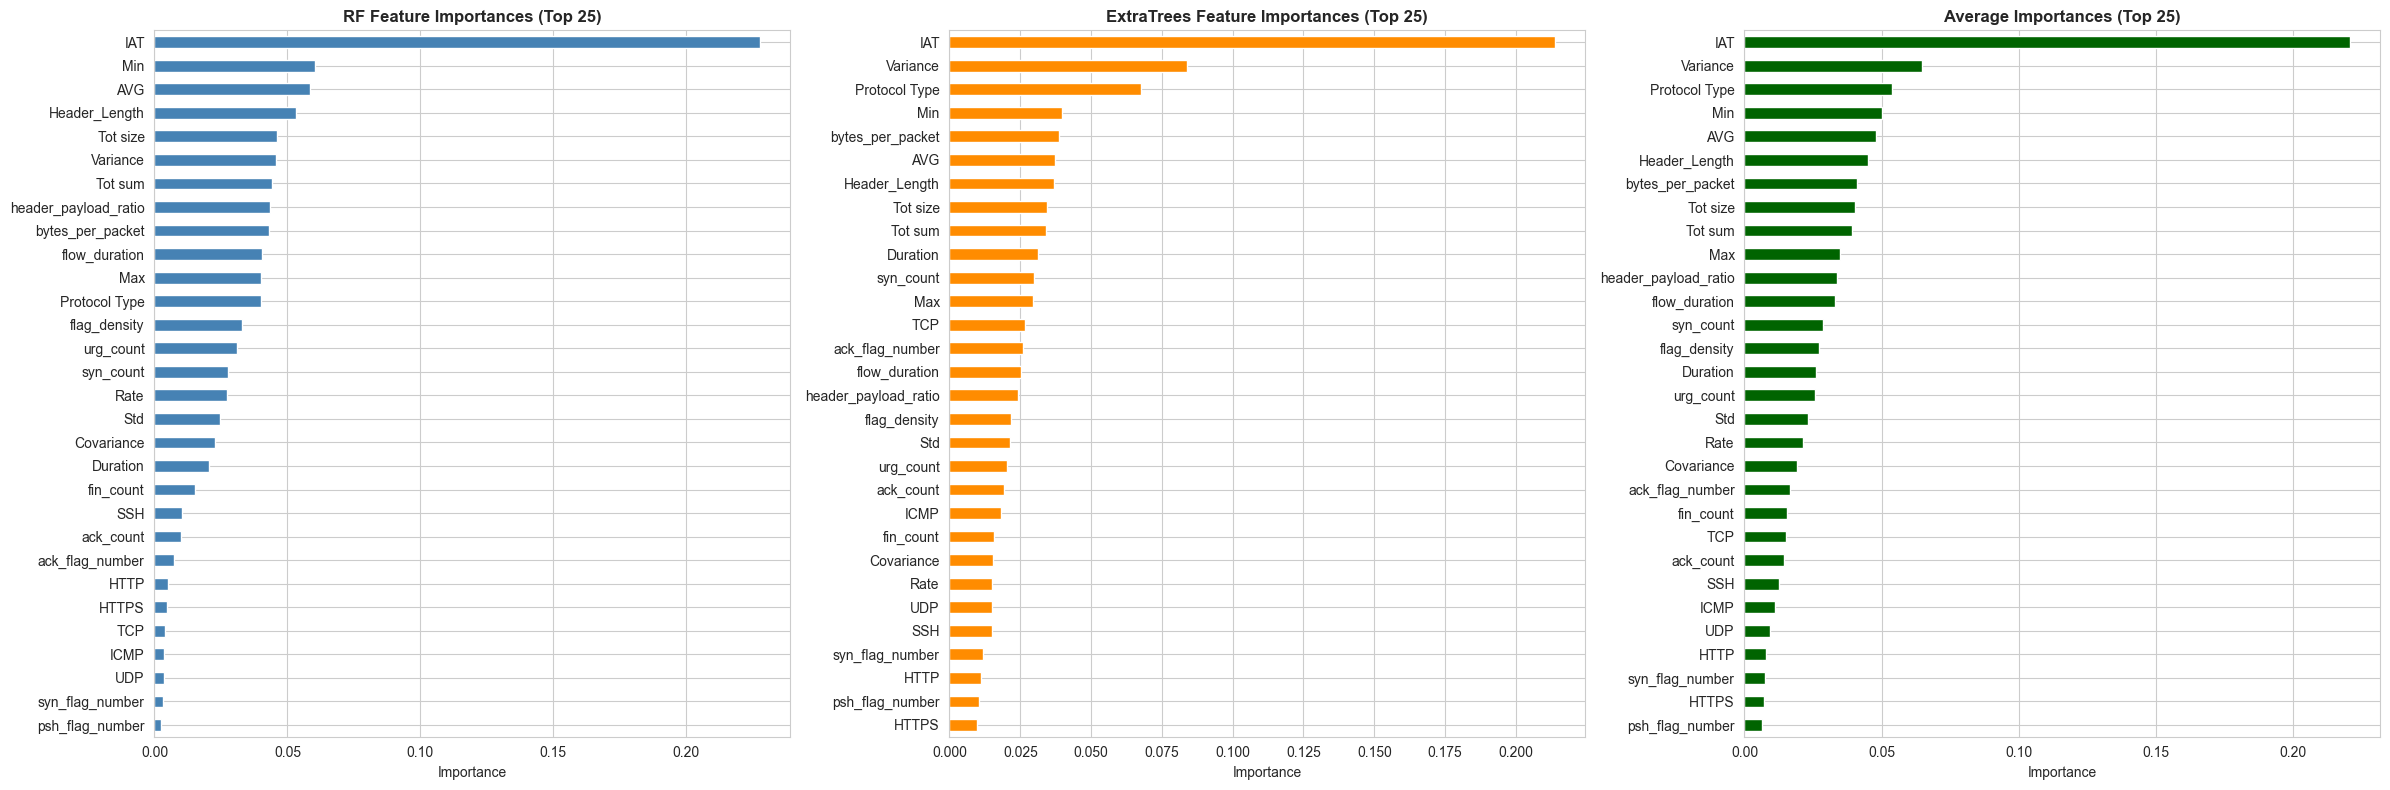

In [ ]:
# Visualize the top 30 feature importances from RF, ET, and their averaged combination.

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

rf_importances.sort_values(ascending=True).tail(TOP_N).plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('RF Feature Importances (Top 25)', fontweight='bold')
axes[0].set_xlabel('Importance')

et_importances.sort_values(ascending=True).tail(TOP_N).plot.barh(ax=axes[1], color='darkorange')
axes[1].set_title('ExtraTrees Feature Importances (Top 25)', fontweight='bold')
axes[1].set_xlabel('Importance')

avg_importances.sort_values(ascending=True).tail(TOP_N).plot.barh(ax=axes[2], color='darkgreen')
axes[2].set_title('Average Importances (Top 25)', fontweight='bold')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [ ]:
# Subset the original training and testing datasets to retain only the top selected features.

X_train_sel = X_train_scaled[top_features]
X_test_sel  = X_test_scaled[top_features]
print(f'Selected features: {X_train_sel.shape[1]} (from {X_train_scaled.shape[1]})')

X_train_tree = X_train_atk[top_features].reset_index(drop=True)
X_test_tree  = X_test_atk[top_features].reset_index(drop=True)

Selected features: 30 (from 40)


---
## Step 5: Compute Boosted Sample Weights

Classes 0 (BruteForce) and 6 (Web) are extreme minorities in this dataset. To prevent the models from ignoring them, I generate balanced sample weights and then apply an additional 1.5x multiplier specifically to these rare classes.



In [ ]:
# Calculate boosted custom sample weights to aggressively penalize misclassifications on rare attack types.

class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train_enc), y=y_train_enc)
class_weight_dict = dict(zip(np.unique(y_train_enc), class_weights_arr))

BOOST_FACTOR = 1.5
base_sw = compute_sample_weight('balanced', y_train_enc)
sample_weights = base_sw.copy()
sample_weights[y_train_enc == 0] *= BOOST_FACTOR  
sample_weights[y_train_enc == 6] *= BOOST_FACTOR  

class_counts = Counter(y_train_enc)
n_total = len(y_train_enc)
custom_cw = {}
for cls in range(num_classes):
    w = n_total / (num_classes * class_counts[cls])
    if cls in [0, 6]:
        w *= BOOST_FACTOR
    custom_cw[cls] = w

print(f'Boost factor: {BOOST_FACTOR}x for classes 0 (BruteForce) & 6 (Web)')
print(f'Weight range: [{sample_weights.min():.4f}, {sample_weights.max():.4f}]')
print('\nClass weights (boosted):')
for c in range(num_classes):
    boost = ' << BOOSTED' if c in [0, 6] else ''
    print(f'  Class {c} ({attack_names[c]:12s}): {custom_cw[c]:.2f}{boost}')

results = {}

Boost factor: 0.8x for classes 0 (BruteForce) & 6 (Web)
Weight range: [0.2082, 51.8590]

Class weights (boosted):
  Class 0 (BruteForce  ): 51.86 << BOOSTED
  Class 1 (DDoS        ): 0.21
  Class 2 (DoS         ): 0.88
  Class 3 (Mirai       ): 2.90
  Class 4 (Recon       ): 2.38
  Class 5 (Spoofing    ): 3.96
  Class 6 (Web         ): 27.22 << BOOSTED


---
## Step 6: Functions

To keep  code clean and avoid repetition, I define a standardized evaluation function here. It automatically calculates macro/weighted F1, Precision, and Recall, plots a confusion matrix, and stores the results for final comparison.



### 6.1 - Evaluate Model

In [ ]:
# Define a comprehensive evaluation function to calculate metrics, print reports, and plot confusion matrices.

def evaluate(name, y_true, y_pred, train_time):
    """Evaluate a model, print metrics, plot confusion matrix, store results."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro')
    f1m = f1_score(y_true, y_pred, average='macro')
    f1w = f1_score(y_true, y_pred, average='weighted')

    results[name] = {
        'accuracy': acc, 'precision': prec, 'recall': rec,
        'f1_macro': f1m, 'f1_weighted': f1w, 'time': train_time
    }

    print(f'\n--- {name} ---')
    print(f'  Accuracy:     {acc:.4f}')
    print(f'  Precision(M): {prec:.4f}')
    print(f'  Recall(M):    {rec:.4f}')
    print(f'  F1(macro):    {f1m:.4f}')
    print(f'  F1(weighted): {f1w:.4f}')
    print(f'  Time:         {train_time:.1f}s')

    pcr = recall_score(y_true, y_pred, average=None)
    for c in range(len(pcr)):
        m = ' ** MINORITY' if c in [0, 6] else ''
        print(f'    Class {c} ({attack_names[c]:12s}) recall: {pcr[c]:.4f}{m}')

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
                xticklabels=attack_names, yticklabels=attack_names,
                annot_kws={'size': 8}, linewidths=0.5)
    axes[0].set_title(f'{name} -- Counts', fontweight='bold')
    axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1],
                xticklabels=attack_names, yticklabels=attack_names,
                annot_kws={'size': 8}, linewidths=0.5)
    axes[1].set_title(f'{name} -- Percentage (%)', fontweight='bold')
    axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')

    plt.tight_layout()
    plt.show()

    print(classification_report(y_true, y_pred, target_names=attack_names))
    return acc, rec, f1m

### 6.2 - Process and Save Tuning Logs


In [ ]:
# Define a universal log processing function to aggregate JSON trial performance for any Optuna model search.
import os
import pandas as pd
import numpy as np
import json

def process_and_save_logs(model_name, trial_prefix, output_filename):
    log_files = [f for f in os.listdir('tuning_logs') if f.startswith(trial_prefix) and f.endswith('.json')]
    
    def get_trial_num(filename):
        return int(filename.split('_')[-1].split('.')[0])
        
    log_files.sort(key=get_trial_num)
    print(f"Processing {model_name} logs...")
    
    with open(output_filename, 'w', encoding='utf-8') as out_file:
        header_text = f"ALL RECONSTRUCTED GLOBAL REPORTS FOR {model_name.upper()}\n\n"
        print(header_text)
        out_file.write(header_text)
        
        for filename in log_files:
            trial_num = get_trial_num(filename)
            filepath = os.path.join('tuning_logs', filename)
            
            with open(filepath, 'r', encoding='utf-8') as file:
                data = json.load(file)
                
            trial_header = f"{'='*50}\n {model_name.upper()} TRIAL {trial_num} | Target Score: {data['score']:.4f}\n{'='*50}\n"
            print(trial_header, end='')
            out_file.write(trial_header)
            
            reports = data['reports']
            classes = [k for k in reports[0].keys() if isinstance(reports[0][k], dict) and k not in ['macro avg', 'weighted avg']]
            
            global_report = {}
            for c in classes:
                total_tp = 0
                total_fp = 0
                total_support = 0
                
                for rep in reports:
                    r = rep[c]
                    support = r['support']
                    recall = r['recall']
                    precision = r['precision']
                    
                    tp = recall * support
                    fp = (tp / precision - tp) if precision > 0 else 0
                    
                    total_tp += tp
                    total_fp += fp
                    total_support += support
                    
                glob_prec = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
                glob_rec = total_tp / total_support if total_support > 0 else 0
                glob_f1 = 2 * (glob_prec * glob_rec) / (glob_prec + glob_rec) if (glob_prec + glob_rec) > 0 else 0
                
                global_report[c] = {
                    'precision': glob_prec,
                    'recall': glob_rec,
                    'f1-score': glob_f1,
                    'support': int(total_support)
                }
                
            df_report = pd.DataFrame(global_report).transpose()
            report_str = df_report[['precision', 'recall', 'f1-score', 'support']].round(4).to_string()
            
            print(report_str + "\n\n")
            out_file.write(report_str + "\n\n\n")
            
    print(f"Execution complete. You can also find the full output saved in '{output_filename}'")


---
## Step 7: Baseline Models

Before doing any complex tuning, I establish a baseline using standard Decision Trees, XGBoost, and Random Forest. This gives me a clear reference point to measure exactly how much my later hyperparameter tuning actually improves the model.




--- Decision Tree Baseline ---

--- Decision Tree Baseline ---
  Accuracy:     0.9886
  Precision(M): 0.8767
  Recall(M):    0.8767
  F1(macro):    0.8767
  F1(weighted): 0.9886
  Time:         58.0s
    Class 0 (BruteForce  ) recall: 0.6822 ** MINORITY
    Class 1 (DDoS        ) recall: 0.9999
    Class 2 (DoS         ) recall: 0.9995
    Class 3 (Mirai       ) recall: 0.9998
    Class 4 (Recon       ) recall: 0.9211
    Class 5 (Spoofing    ) recall: 0.8810
    Class 6 (Web         ) recall: 0.6535 ** MINORITY


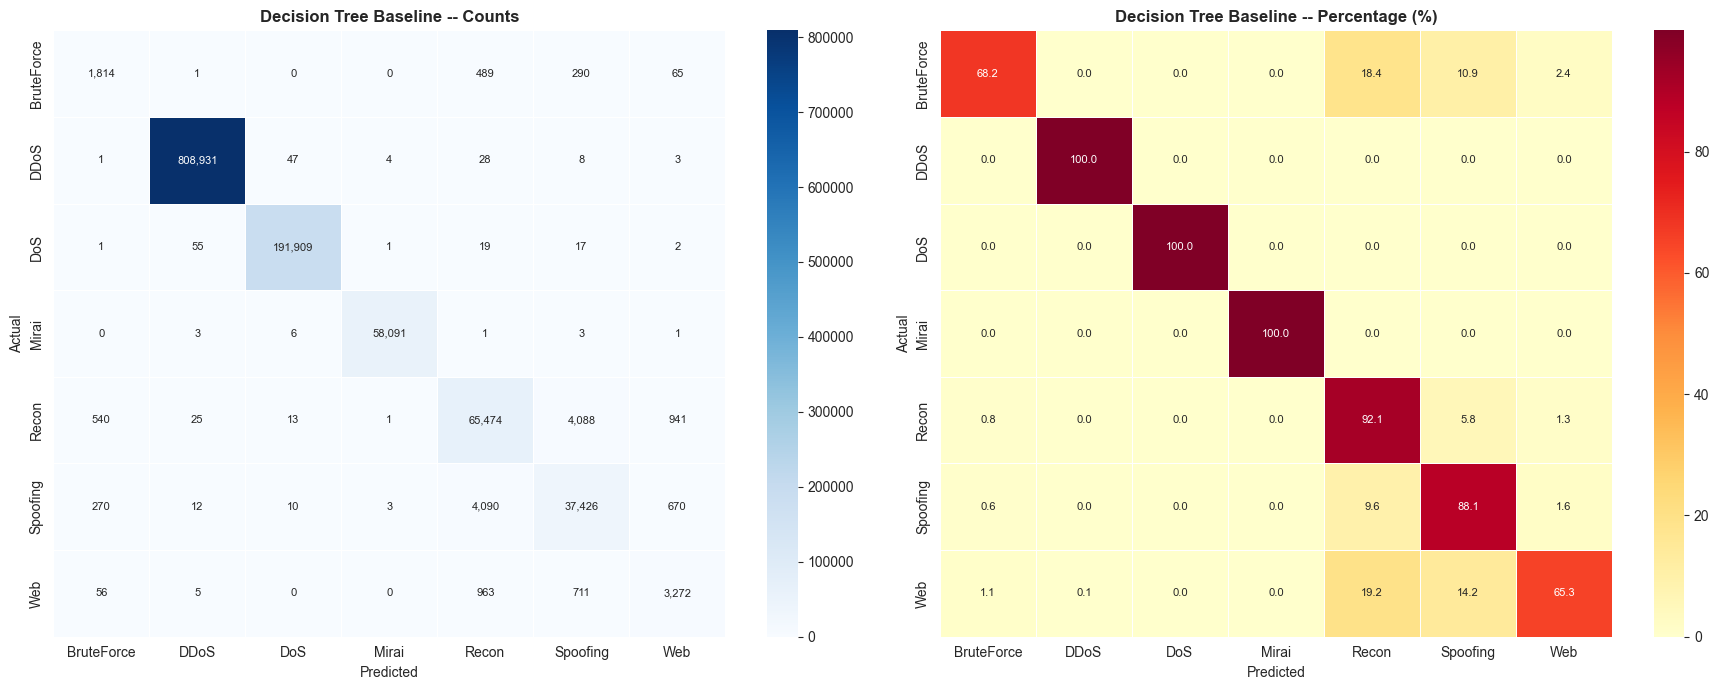

              precision    recall  f1-score   support

  BruteForce       0.68      0.68      0.68      2659
        DDoS       1.00      1.00      1.00    809022
         DoS       1.00      1.00      1.00    192004
       Mirai       1.00      1.00      1.00     58105
       Recon       0.92      0.92      0.92     71082
    Spoofing       0.88      0.88      0.88     42481
         Web       0.66      0.65      0.66      5007

    accuracy                           0.99   1180360
   macro avg       0.88      0.88      0.88   1180360
weighted avg       0.99      0.99      0.99   1180360



(0.9886111016977871, 0.8767084430002848, 0.8767226883115844)

In [ ]:
# Train and evaluate a baseline Decision Tree model using standard balanced weights.

from sklearn.tree import DecisionTreeClassifier
print('\n--- Decision Tree Baseline ---')
t0 = time.time()
dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_base.fit(X_train_tree, y_train_enc)
dt_time = time.time() - t0
y_pred_dt = dt_base.predict(X_test_tree)
evaluate('Decision Tree Baseline', y_test_enc, y_pred_dt, dt_time)

### 7.2 - XGBoost Baseline


In [ ]:
# Train and evaluate a baseline XGBoost model utilizing the custom boosted sample weights.

print('Training XGBoost (baseline) with boosted sample weights...')
t0 = time.time()
xgb_base = XGBClassifier(reg_alpha=0.3, reg_lambda=0.6, device='cuda', tree_method='hist', random_state=42)
xgb_base.fit(X_train_tree, y_train_enc, sample_weight=sample_weights)
xgb_time = time.time() - t0
y_pred_xgb = xgb_base.predict(X_test_tree)
evaluate('XGB Baseline', y_test_enc, y_pred_xgb, xgb_time)


### 7.3 - Random Forest Baseline 


Training Random Forest (baseline) with boosted class weights...

--- RF Baseline ---
  Accuracy:     0.9908
  Precision(M): 0.9692
  Recall(M):    0.8571
  F1(macro):    0.8980
  F1(weighted): 0.9905
  Time:         150.6s
    Class 0 (BruteForce  ) recall: 0.6055 ** MINORITY
    Class 1 (DDoS        ) recall: 0.9999
    Class 2 (DoS         ) recall: 0.9993
    Class 3 (Mirai       ) recall: 0.9973
    Class 4 (Recon       ) recall: 0.9715
    Class 5 (Spoofing    ) recall: 0.8790
    Class 6 (Web         ) recall: 0.5468 ** MINORITY


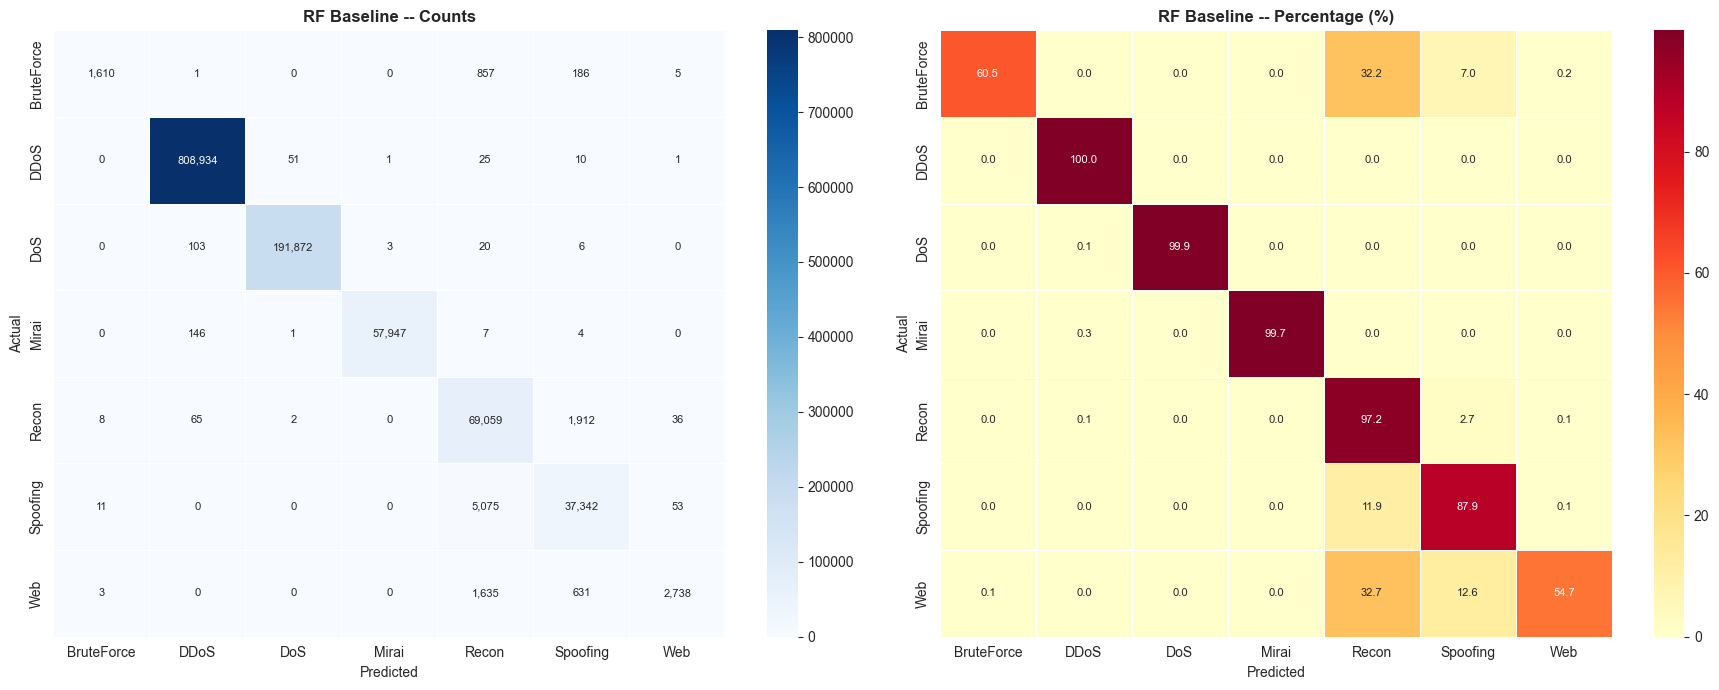

              precision    recall  f1-score   support

  BruteForce       0.99      0.61      0.75      2659
        DDoS       1.00      1.00      1.00    809022
         DoS       1.00      1.00      1.00    192004
       Mirai       1.00      1.00      1.00     58105
       Recon       0.90      0.97      0.93     71082
    Spoofing       0.93      0.88      0.90     42481
         Web       0.97      0.55      0.70      5007

    accuracy                           0.99   1180360
   macro avg       0.97      0.86      0.90   1180360
weighted avg       0.99      0.99      0.99   1180360



(0.9908011115252974, 0.8570539895312723, 0.8979949469062877)

In [ ]:
# Train and evaluate a baseline Random Forest model utilizing custom boosted class weights.

print('Training Random Forest (baseline) with boosted class weights...')
t0 = time.time()
rf_base = RandomForestClassifier(
    n_estimators=100, class_weight=custom_cw, random_state=42, n_jobs=-1
)
rf_base.fit(X_train_tree, y_train_enc)
rf_time = time.time() - t0
y_pred_rf = rf_base.predict(X_test_tree)
evaluate('RF Baseline', y_test_enc, y_pred_rf, rf_time)

### 7.4 - Baseline Comparison


In [ ]:
# Extract and display a comparative DataFrame of the performance metrics for the three baseline models.

baseline_df = pd.DataFrame(results).T
baseline_df = baseline_df[['accuracy', 'precision', 'recall', 'f1_macro', 'f1_weighted', 'time']]
baseline_df.columns = ['Accuracy', 'Precision(M)', 'Recall(M)', 'F1(macro)', 'F1(weighted)', 'Time(s)']
print('Baseline Comparison:')
baseline_df

Baseline Comparison:


,Accuracy,Precision(M),Recall(M),F1(macro),F1(weighted),Time(s)
Decision Tree Baseline,0.988611,0.876746,0.876708,0.876723,0.988609,58.020498
XGB Baseline,0.986266,0.804158,0.924684,0.834721,0.987984,78.857823
RF Baseline,0.990801,0.969188,0.857054,0.897995,0.990473,150.604140


---
## Step 8: Optuna Hyperparameter Tuning

utilize Optuna to systematically search for the best hyperparameters for both XGBoost and Random Forest. The objective function is customized to maximize Macro F1 and Precision, heavily punishing misclassifications on our minority classes.



In [ ]:
# Set up Stratified K-Fold cross-validation and directory structure for structured Optuna hyperparameter tuning.


os.makedirs('tuning_logs', exist_ok=True)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


### 8.1 - XGBoost Objective Function

In [ ]:
# Define the Optuna objective function for XGBoost using Softprob and Stratified Fold cross-validation.

def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 3.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 3.0),
        'objective': 'multi:softprob', 
        'num_class': num_classes,
        'eval_metric': 'mlogloss',
        'device': 'cuda', 
        'tree_method': 'hist', 
        'random_state': 42
    }
    
    scores = []
    trial_reports = []
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_tree, y_train_enc)):
        model = XGBClassifier(**params)
        sw_fold = sample_weights[train_idx]
        
        model.fit(X_train_tree.iloc[train_idx], y_train_enc.iloc[train_idx],
                  sample_weight=sw_fold)
                  
        y_pred = model.predict(X_train_tree.iloc[val_idx])
        
        macro_f1 = f1_score(y_train_enc.iloc[val_idx], y_pred, average='macro')
        macro_prec = precision_score(y_train_enc.iloc[val_idx], y_pred, average='macro', zero_division=0)
        combined_score = (0.5 * macro_f1) + (0.5 * macro_prec)
        
        scores.append(combined_score)
        
        rep = classification_report(y_train_enc.iloc[val_idx], y_pred, output_dict=True, zero_division=0)
        trial_reports.append(rep)
        
    avg_score = np.mean(scores)
    
    with open(f'tuning_logs/xgb_trial_{trial.number}.json', 'w') as f:
        json.dump({'params': params, 'score': avg_score, 'reports': trial_reports}, f, indent=2)
        
    return avg_score


### 8.2 - Tune XGBoost

In [ ]:
# Create the Optuna study and execute the optimization process for XGBoost to find the best macro F1.

study_xgb = optuna.create_study(direction='maximize')

study_xgb.optimize(xgb_objective, n_trials=40, show_progress_bar=True)

print(f'\nBest XGBoost score: {study_xgb.best_value:.4f}')
print(f'Best params: {study_xgb.best_params}')
# Train best XGB
best_xgb_p = study_xgb.best_params.copy()
best_xgb_p.update({
    'objective': 'multi:softprob', 
    'num_class': num_classes, 
    'eval_metric': 'mlogloss', 
    'device': 'cuda', 
    'tree_method': 'hist', 
    'random_state': 42
})

t0 = time.time()
xgb_tuned = XGBClassifier(**best_xgb_p)
xgb_tuned.fit(X_train_tree, y_train_enc, sample_weight=sample_weights) 
xgb_t_time = time.time() - t0

y_pred_xgb_t = xgb_tuned.predict(X_test_tree)
evaluate('XGB Tuned', y_test_enc, y_pred_xgb_t, xgb_t_time)


### 8.3 - Evaluate Best Minority XGB Trial

In [ ]:
# Read through the saved Optuna JSON logs to find the single trial that maximized precision for minority classes 0 and 6.

best_minority_score = -1
best_minority_params = None
best_trial_name = ""

# Loop through all saved JSON trial reports
for filename in os.listdir('tuning_logs'):
    if filename.startswith('xgb_trial_') and filename.endswith('.json'):
        filepath = os.path.join('tuning_logs', filename)
        
        with open(filepath, 'r') as f:
            data = json.load(f)
            
        reports = data['reports']
        prec_0 = np.mean([rep.get('0', {}).get('precision', 0) for rep in reports])
        prec_6 = np.mean([rep.get('6', {}).get('precision', 0) for rep in reports])
        
        combined_minority_prec = (prec_0 + prec_6) / 2
        
        if combined_minority_prec > best_minority_score:
            best_minority_score = combined_minority_prec
            best_minority_params = data['params']
            best_trial_name = filename

print(f" Best Trial for Classes 0 & 6: {best_trial_name}")
print(f"Average Precision for 0 & 6: {best_minority_score:.4f}")
print("Best Minority Parameters:")
for k, v in best_minority_params.items():
    print(f"  {k}: {v}")

🏆 Best Trial for Classes 0 & 6: xgb_trial_7.json
Average Precision for 0 & 6: 0.7620
Best Minority Parameters:
  n_estimators: 813
  max_depth: 14
  learning_rate: 0.03155351754179053
  subsample: 0.7768127704260512
  colsample_bytree: 0.7360321458673789
  colsample_bylevel: 0.7507887126606865
  min_child_weight: 1
  gamma: 2.0299977786789896
  reg_alpha: 2.4201133150794405
  reg_lambda: 1.2375371318109456
  objective: multi:softprob
  num_class: 7
  eval_metric: mlogloss
  device: cuda
  tree_method: hist
  random_state: 42


### 8.4 - Process and Save XGB Tuning Logs


In [ ]:
# Aggregate trial reports from the XGBoost search and write a consolidated summary text file.
process_and_save_logs('XGBoost', 'xgb_trial_', 'ALL_XGB_TRIALS_REPORTS.txt')


### 8.5 - Tune Random Forest Setup


In [ ]:
# Suppress excessive Optuna logging before starting the Random Forest search.

print('\n--- Tuning Random Forest (30 trials, Pure Class Weights) ---')
optuna.logging.set_verbosity(optuna.logging.INFO)


### 8.6 - Random Forest Objective Function


In [ ]:
# Define the Random Forest Optuna objective function. We test Custom vs Balanced class weights here.

def rf_objective(trial):
    cw_choice = trial.suggest_categorical('class_weight_type', ['balanced', 'custom'])
    cw_val = 'balanced' if cw_choice == 'balanced' else custom_cw
    
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'max_depth': trial.suggest_int('max_depth', 10, 60),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'class_weight': cw_val, 
        'random_state': 42, 
        'n_jobs': -1  
    }
    
    scores = []
    trial_reports = []
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_tree, y_train_enc)):
        model = RandomForestClassifier(**params)
        model.fit(X_train_tree.iloc[train_idx], y_train_enc.iloc[train_idx])
        y_pred = model.predict(X_train_tree.iloc[val_idx])
        
        macro_f1 = f1_score(y_train_enc.iloc[val_idx], y_pred, average='macro')
        macro_rec = recall_score(y_train_enc.iloc[val_idx], y_pred, average='macro')
        combined_score = (0.5 * macro_f1) + (0.5 * macro_rec)
        
        scores.append(combined_score)
        
        rep = classification_report(y_train_enc.iloc[val_idx], y_pred, output_dict=True, zero_division=0)
        trial_reports.append(rep)
        
    avg_score = np.mean(scores)
    
    # Save trial report
    with open(f'tuning_logs/rf_trial_{trial.number}.json', 'w') as f:
        json.dump({'params': params, 'score': avg_score, 'reports': trial_reports}, f, indent=2)
        
    return avg_score


### 8.7 -Tune Random Forest


In [ ]:
# Run the Random Forest study, then immediately instantiate and fit the final tuned RF model.

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(rf_objective, n_trials=30, n_jobs=-1, show_progress_bar=True)
print(f'Best RF score: {study_rf.best_value:.4f}')
print(f'Best params: {study_rf.best_params}')

# Train best RF
best_rf_p = study_rf.best_params.copy()
cw_final_rf = 'balanced' if best_rf_p.pop('class_weight_type') == 'balanced' else custom_cw
best_rf_p.update({'class_weight': cw_final_rf, 'random_state': 42, 'n_jobs': -1})

t0 = time.time()
rf_tuned = RandomForestClassifier(**best_rf_p)
rf_tuned.fit(X_train_tree, y_train_enc)
rf_t_time = time.time() - t0
y_pred_rf_t = rf_tuned.predict(X_test_tree)
evaluate('RF Tuned', y_test_enc, y_pred_rf_t, rf_t_time)


--- RF Tuned ---
  Accuracy:     0.9916
  Precision(M): 0.9252
  Recall(M):    0.8947
  F1(macro):    0.9084
  F1(weighted): 0.9916
  Time:         2038.2s
    Class 0 (BruteForce  ) recall: 0.6965 ** MINORITY
    Class 1 (DDoS        ) recall: 0.9999
    Class 2 (DoS         ) recall: 0.9998
    Class 3 (Mirai       ) recall: 0.9998
    Class 4 (Recon       ) recall: 0.9461
    Class 5 (Spoofing    ) recall: 0.9150
    Class 6 (Web         ) recall: 0.7060 ** MINORITY


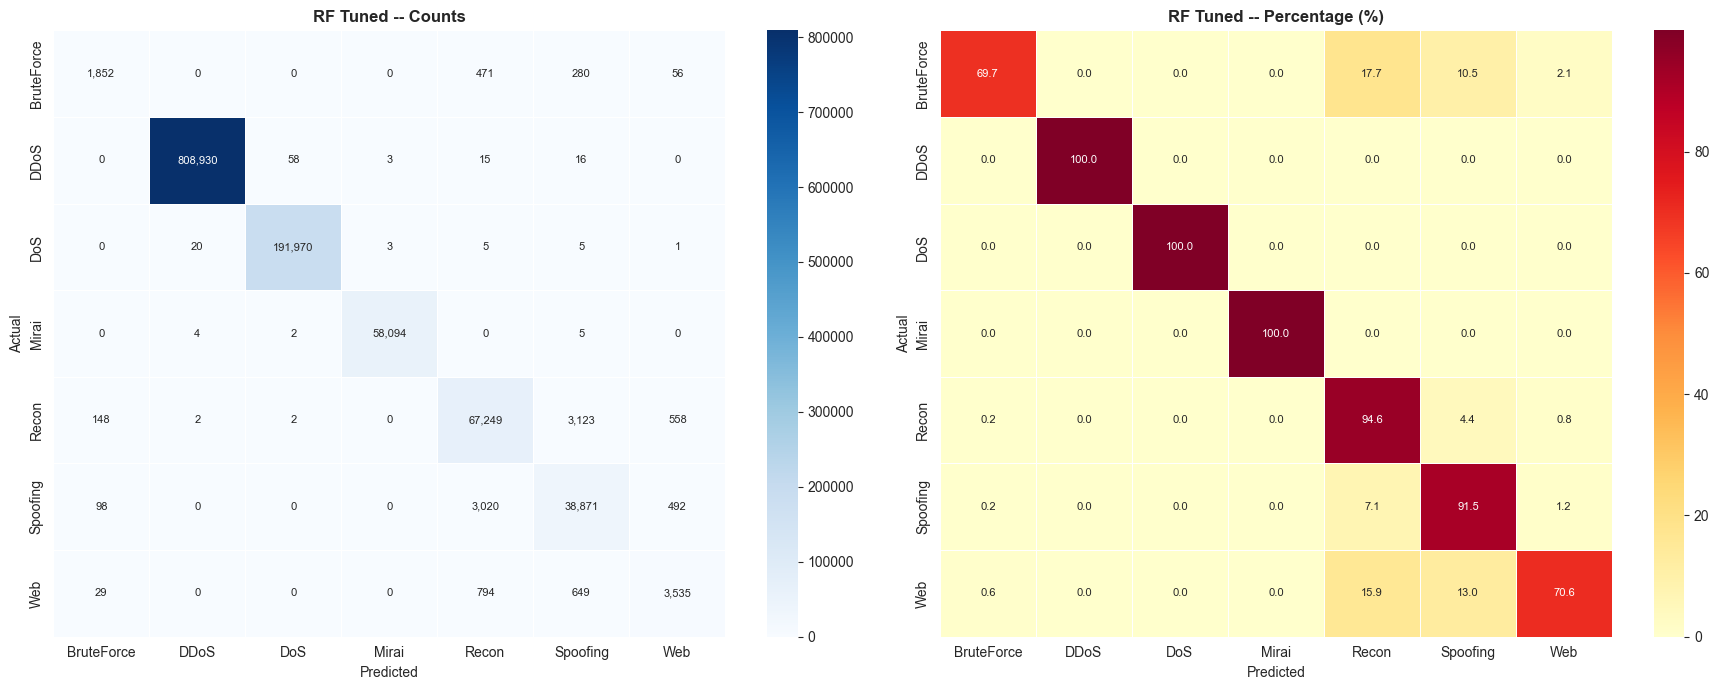

              precision    recall  f1-score   support

  BruteForce       0.87      0.70      0.77      2659
        DDoS       1.00      1.00      1.00    809022
         DoS       1.00      1.00      1.00    192004
       Mirai       1.00      1.00      1.00     58105
       Recon       0.94      0.95      0.94     71082
    Spoofing       0.91      0.92      0.91     42481
         Web       0.76      0.71      0.73      5007

    accuracy                           0.99   1180360
   macro avg       0.93      0.89      0.91   1180360
weighted avg       0.99      0.99      0.99   1180360



(0.9916474634857162, 0.8947330162883496, 0.9084467192461425)

In [ ]:
best_rf_p = study_rf.best_params.copy()
best_rf_p.update({'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1})
t0 = time.time()
rf_tuned = RandomForestClassifier(**best_rf_p)
rf_tuned.fit(X_train_tree, y_train_enc)
rf_t_time = time.time() - t0
y_pred_rf_t = rf_tuned.predict(X_test_tree)
evaluate('RF Tuned', y_test_enc, y_pred_rf_t, rf_t_time)

### 8.9 - Tuned vs Baselines Comparison


In [ ]:
# Compile the metrics for Baseline vs. Tuned models into a single DataFrame for easy comparison.

all_df = pd.DataFrame(results).T
all_df = all_df[['accuracy', 'precision', 'recall', 'f1_macro', 'f1_weighted', 'time']]
all_df.columns = ['Accuracy', 'Precision(M)', 'Recall(M)', 'F1(macro)', 'F1(weighted)', 'Time(s)']
print('All Models Comparison:')
all_df.sort_values('F1(macro)', ascending=False)

All Models Comparison:


,Accuracy,Precision(M),Recall(M),F1(macro),F1(weighted),Time(s)
RF Tuned,0.991647,0.925238,0.894733,0.908447,0.991584,2038.212445
RF Baseline,0.990801,0.969188,0.857054,0.897995,0.990473,150.604140
Decision Tree Baseline,0.988611,0.876746,0.876708,0.876723,0.988609,58.020498
XGB Baseline,0.986266,0.804158,0.924684,0.834721,0.987984,78.857823


---
## Step 9: Ensemble Models

Even with heavily tuned models, individual algorithms have blind spots. Here, I combine the strengths of both XGBoost and Random Forest using two strategies:
1. **Voting (Soft)**: Averages their predicted probabilities.
2. **Stacking**: Uses a Logistic Regression meta-model to learn *when* to trust XGBoost vs Random Forest.



Training Voting Ensemble (soft)...

--- Voting Ensemble ---
  Accuracy:     0.9918
  Precision(M): 0.9189
  Recall(M):    0.9046
  F1(macro):    0.9110
  F1(weighted): 0.9918
  Time:         3120.6s
    Class 0 (BruteForce  ) recall: 0.7273 ** MINORITY
    Class 1 (DDoS        ) recall: 0.9998
    Class 2 (DoS         ) recall: 0.9999
    Class 3 (Mirai       ) recall: 0.9998
    Class 4 (Recon       ) recall: 0.9386
    Class 5 (Spoofing    ) recall: 0.9286
    Class 6 (Web         ) recall: 0.7384 ** MINORITY


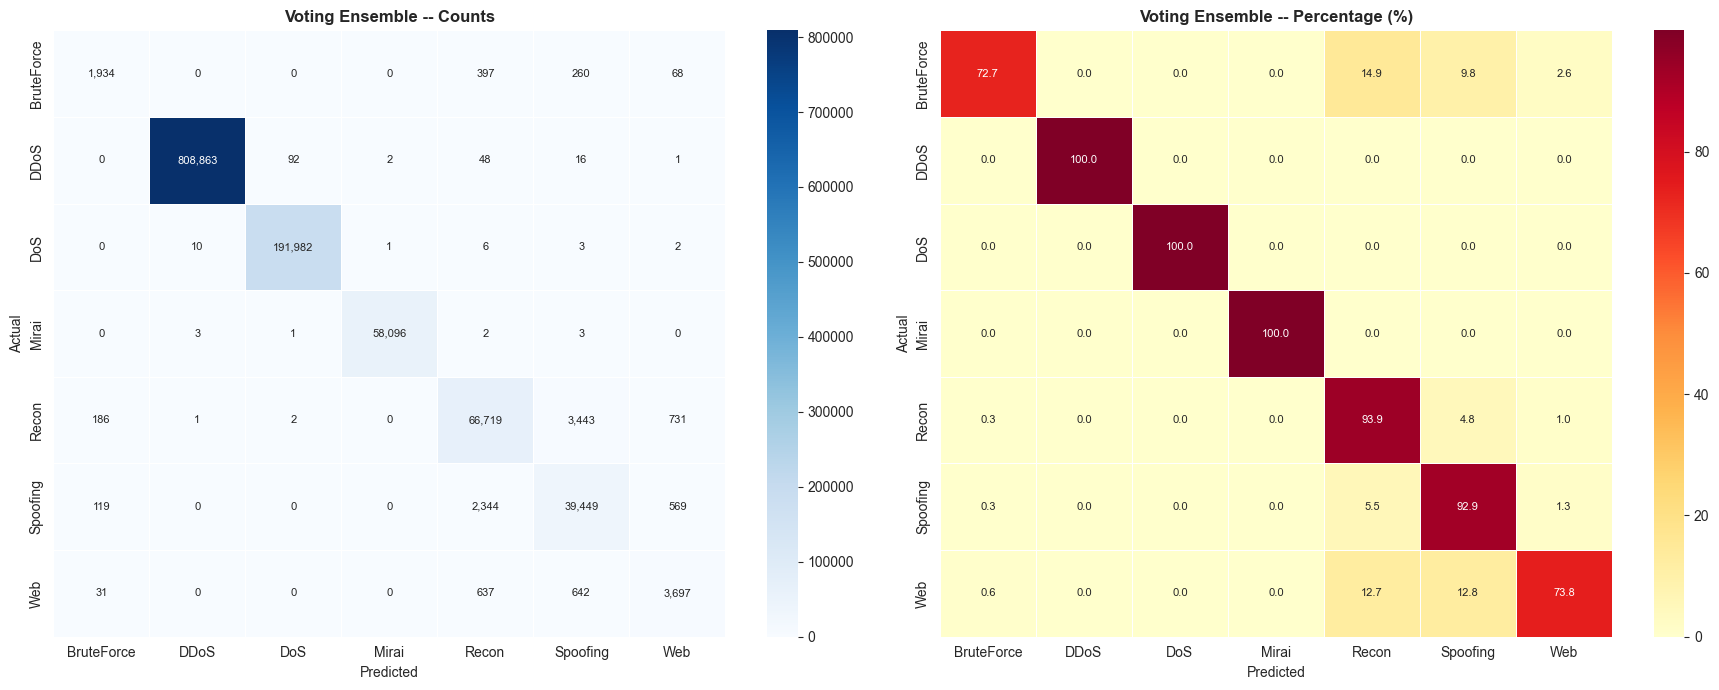

              precision    recall  f1-score   support

  BruteForce       0.85      0.73      0.78      2659
        DDoS       1.00      1.00      1.00    809022
         DoS       1.00      1.00      1.00    192004
       Mirai       1.00      1.00      1.00     58105
       Recon       0.95      0.94      0.94     71082
    Spoofing       0.90      0.93      0.91     42481
         Web       0.73      0.74      0.73      5007

    accuracy                           0.99   1180360
   macro avg       0.92      0.90      0.91   1180360
weighted avg       0.99      0.99      0.99   1180360



(0.9918499440848555, 0.9046412124332568, 0.9110256671691496)

In [ ]:
# Train a soft-voting ensemble model combining the predictions of the tuned XGBoost and RF classifiers.

print('Training Voting Ensemble (soft)...')
t0 = time.time()
voting = VotingClassifier(
    estimators=[('xgb', xgb_tuned), ('rf', rf_tuned)],
    voting='soft'
)
voting.fit(X_train_tree, y_train_enc, sample_weight=sample_weights)
voting_time = time.time() - t0
y_pred_vote = voting.predict(X_test_tree)
evaluate('Voting Ensemble', y_test_enc, y_pred_vote, voting_time)

### 9.2 - Stacking Ensemble


Training Stacking Ensemble...

--- Stacking Ensemble ---
  Accuracy:     0.9884
  Precision(M): 0.8180
  Recall(M):    0.9295
  F1(macro):    0.8498
  F1(weighted): 0.9897
  Time:         19919.0s
    Class 0 (BruteForce  ) recall: 0.8597 ** MINORITY
    Class 1 (DDoS        ) recall: 0.9998
    Class 2 (DoS         ) recall: 0.9999
    Class 3 (Mirai       ) recall: 0.9998
    Class 4 (Recon       ) recall: 0.8921
    Class 5 (Spoofing    ) recall: 0.8864
    Class 6 (Web         ) recall: 0.8688 ** MINORITY


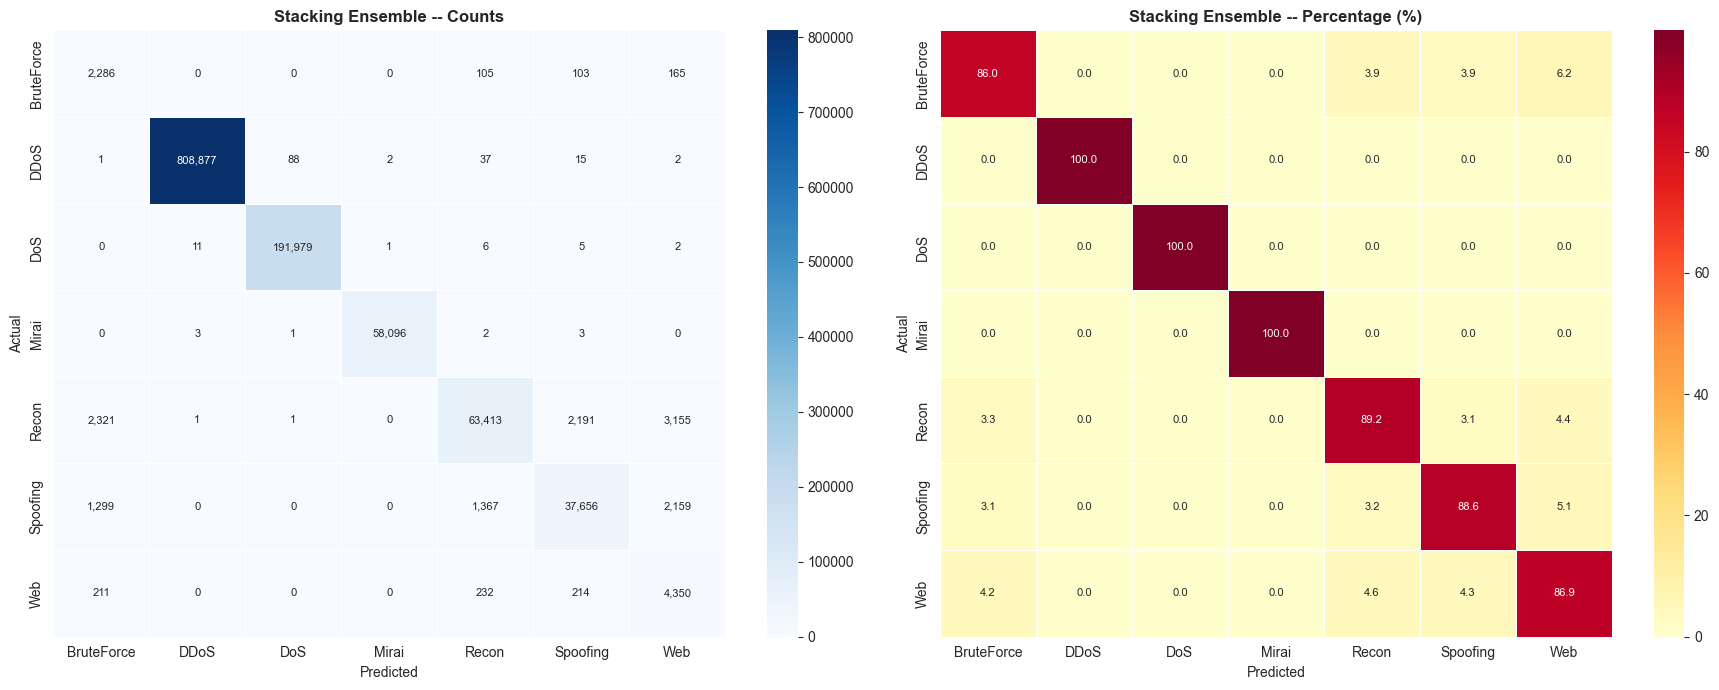

              precision    recall  f1-score   support

  BruteForce       0.37      0.86      0.52      2659
        DDoS       1.00      1.00      1.00    809022
         DoS       1.00      1.00      1.00    192004
       Mirai       1.00      1.00      1.00     58105
       Recon       0.97      0.89      0.93     71082
    Spoofing       0.94      0.89      0.91     42481
         Web       0.44      0.87      0.59      5007

    accuracy                           0.99   1180360
   macro avg       0.82      0.93      0.85   1180360
weighted avg       0.99      0.99      0.99   1180360



(0.9883908299162967, 0.9295102011118301, 0.8497928982517227)

In [ ]:
# Train a stacking ensemble model that uses Logistic Regression as the final meta-estimator.

print('Training Stacking Ensemble...')
t0 = time.time()
stacking = StackingClassifier(
    estimators=[('xgb', xgb_tuned), ('rf', rf_tuned)],
    final_estimator=LogisticRegression(max_iter=1000, solver='lbfgs',
                                       class_weight='balanced', random_state=42),
    cv=3, n_jobs=-1
)
stacking.fit(X_train_tree, y_train_enc, sample_weight=sample_weights)
stacking_time = time.time() - t0
y_pred_stack = stacking.predict(X_test_tree)
evaluate('Stacking Ensemble', y_test_enc, y_pred_stack, stacking_time)

---
## Step 10: Per-Class Threshold Tuning

Traditional `argmax` probability assignment hurts our rare classes. Instead, I computationally search for optimal threshold multipliers. By amplifying the predicted probabilities for BruteForce and Web, I encourage the model to confidently predict them when it sees subtle patterns.



### 10.1 - Find Best Thresholds

In [ ]:
# ── NEW: Create a held-out validation set from training data for threshold tuning ──
# This ensures the test set remains completely untouched during threshold optimization.
from sklearn.model_selection import train_test_split

X_train_thresh, X_val_thresh, y_train_thresh, y_val_thresh = train_test_split(
    X_train_tree, y_train_enc,
    test_size=0.2,
    stratify=y_train_enc,
    random_state=42
)
print(f'Threshold-tuning split: train={len(X_train_thresh)}, val={len(X_val_thresh)}')


In [ ]:
# Extract predicted probabilities on the VALIDATION set (not test) and search for best thresholds.
# This prevents data leakage: thresholds are optimized on held-out validation data only.
print('2. Extracting probabilities for threshold tuning on VALIDATION set...')
y_proba_val = xgb_tuned.predict_proba(X_val_thresh)

best_thresh = np.ones(num_classes)
best_f1 = 0

thresh_vals = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2, 1.5, 2.0, 2.5, 3.0]

print('Searching threshold multipliers for classes 0 & 6...')
for t0_v in thresh_vals:
    for t6_v in thresh_vals:
        th = np.ones(num_classes)
        th[0] = t0_v
        th[6] = t6_v
        
        adj = y_proba_val * th
        pred = np.argmax(adj, axis=1)
        
        mf1 = f1_score(y_val_thresh, pred, average='macro')
        
        if mf1 > best_f1:
            best_f1 = mf1
            best_thresh = th.copy()

print(f'\n Best thresholds (tuned on validation set): {best_thresh}')
print(f' Best macro F1 on validation set: {best_f1:.4f}')


### 10.2 - Apply Thresholds & Evaluate

In [ ]:
# Apply the chosen threshold multipliers to the UNTOUCHED TEST SET and evaluate.
# The thresholds were tuned on the validation split — this is a true out-of-sample evaluation.

y_proba_test = xgb_tuned.predict_proba(X_test_tree)
adj_proba = y_proba_test * best_thresh
y_pred_thresh = np.argmax(adj_proba, axis=1)

evaluate('XGB Threshold-Tuned', y_test_enc, y_pred_thresh, xgb_t_time)


In [ ]:
# Compare the per-class recall scores before and after applying the tuned decision thresholds.

print('Per-class Recall: XGB Tuned vs Threshold-Tuned')
rec_b = recall_score(y_test_enc, y_pred_rf_t, average=None)
rec_a = recall_score(y_test_enc, y_pred_thresh, average=None)
for c in range(num_classes):
    d = rec_a[c] - rec_b[c]
    arrow = '+' if d > 0 else ''
    m = ' << IMPROVED' if d > 0.01 else ''
    print(f'  Class {c} ({attack_names[c]:12s}): {rec_b[c]:.4f} -> {rec_a[c]:.4f} ({arrow}{d:.4f}){m}')

Per-class Recall: XGB Tuned vs Threshold-Tuned
  Class 0 (BruteForce  ): 0.6965 -> 0.6909 (-0.0056)
  Class 1 (DDoS        ): 0.9999 -> 0.9994 (-0.0004)
  Class 2 (DoS         ): 0.9998 -> 0.9998 (+0.0000)
  Class 3 (Mirai       ): 0.9998 -> 0.9999 (+0.0001)
  Class 4 (Recon       ): 0.9461 -> 0.9459 (-0.0002)
  Class 5 (Spoofing    ): 0.9150 -> 0.9283 (+0.0132) << IMPROVED
  Class 6 (Web         ): 0.7060 -> 0.6818 (-0.0242)


---
## Step 11: Final Comparison and  Save

In this final step, I compile all the metrics from the baselines, the tuned models, and the ensembles into a single DataFrame. I sort them by Macro F1 to objectively identify the absolute best performing model, which I then serialize (pickle) along with its label encoders for future deployment.



In [ ]:
# Build the final results DataFrame and print a ranked summary of all trained models based on Macro F1 score.

final_df = pd.DataFrame(results).T
final_df = final_df[['accuracy', 'precision', 'recall', 'f1_macro', 'f1_weighted', 'time']]
final_df.columns = ['Accuracy', 'Precision(M)', 'Recall(M)', 'F1(macro)', 'F1(weighted)', 'Time(s)']
final_df = final_df.sort_values('F1(macro)', ascending=False)

print('=' * 70)
print('  FINAL RANKING -- 7-Class Attack Classification V2')
print('=' * 70)
for rank, (name, row) in enumerate(final_df.iterrows(), 1):
    m = ' <- WINNER' if rank == 1 else ''
    print(f'  #{rank} {name:25s}  F1(M)={row["F1(macro)"]:.4f}  '
          f'F1(W)={row["F1(weighted)"]:.4f}  '
          f'Acc={row["Accuracy"]:.4f}  '
          f'Rec={row["Recall(M)"]:.4f}{m}')
print('=' * 70)

final_df

  FINAL RANKING -- 7-Class Attack Classification V2
  #1 XGB Threshold-Tuned        F1(M)=0.9130  F1(W)=0.9916  Acc=0.9917  Rec=0.8923 <- WINNER
  #2 Voting Ensemble            F1(M)=0.9110  F1(W)=0.9918  Acc=0.9918  Rec=0.9046
  #3 RF Tuned                   F1(M)=0.9084  F1(W)=0.9916  Acc=0.9916  Rec=0.8947
  #4 RF Baseline                F1(M)=0.8980  F1(W)=0.9905  Acc=0.9908  Rec=0.8571
  #5 Decision Tree Baseline     F1(M)=0.8767  F1(W)=0.9886  Acc=0.9886  Rec=0.8767
  #6 Stacking Ensemble          F1(M)=0.8498  F1(W)=0.9897  Acc=0.9884  Rec=0.9295
  #7 XGB Baseline               F1(M)=0.8347  F1(W)=0.9880  Acc=0.9863  Rec=0.9247


,Accuracy,Precision(M),Recall(M),F1(macro),F1(weighted),Time(s)
XGB Threshold-Tuned,0.991700,0.940188,0.892289,0.912956,0.991607,111.127194
Voting Ensemble,0.991850,0.918897,0.904641,0.911026,0.991848,3120.572331
RF Tuned,0.991647,0.925238,0.894733,0.908447,0.991584,2038.212445
RF Baseline,0.990801,0.969188,0.857054,0.897995,0.990473,150.604140
Decision Tree Baseline,0.988611,0.876746,0.876708,0.876723,0.988609,58.020498
Stacking Ensemble,0.988391,0.817954,0.929510,0.849793,0.989679,19918.990511
XGB Baseline,0.986266,0.804158,0.924684,0.834721,0.987984,78.857823


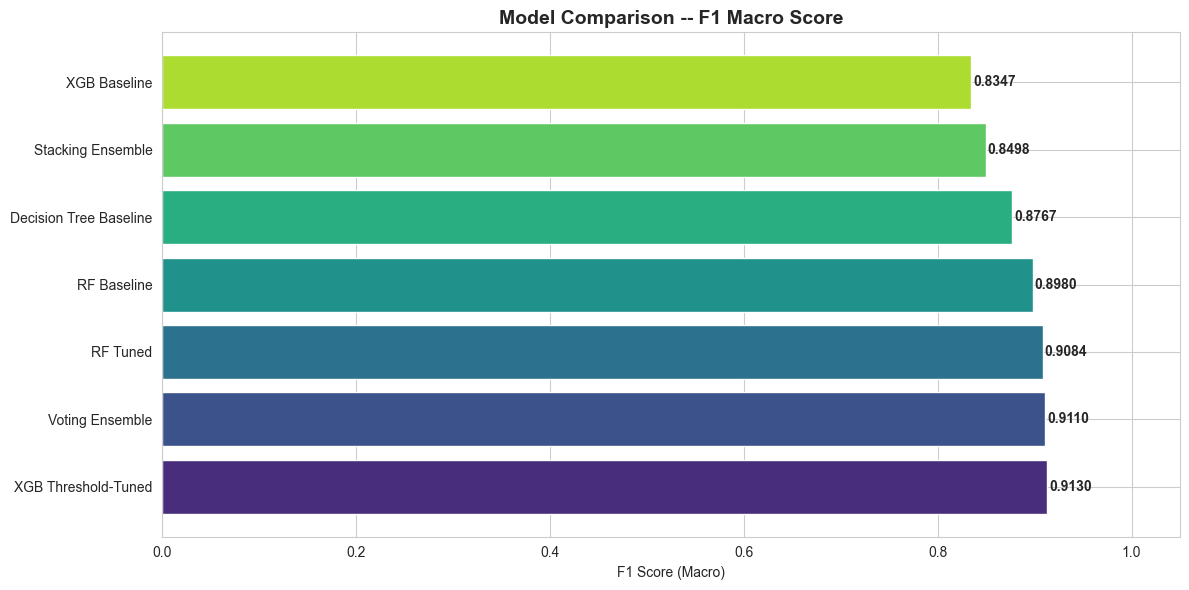

In [ ]:
# Plot a horizontal bar chart visualizing the final Macro F1 rankings across all evaluated models.

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('viridis', len(final_df))
bars = ax.barh(range(len(final_df)), final_df['F1(macro)'], color=colors)
ax.set_yticks(range(len(final_df)))
ax.set_yticklabels(final_df.index)
ax.set_xlabel('F1 Score (Macro)')
ax.set_title('Model Comparison -- F1 Macro Score', fontweight='bold', fontsize=14)
for i, v in enumerate(final_df['F1(macro)']):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontweight='bold')
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.show()

### Save Best Model


In [ ]:
# Determine the absolute best model from the rankings and serialize it alongside scalers and encoders via pickle.

best_name = final_df.index[0]
models_dict = {
    'XGB Baseline': xgb_base, 'RF Baseline': rf_base,
    'XGB Tuned': xgb_tuned, 'RF Tuned': rf_tuned,
    'Voting Ensemble': voting, 'Stacking Ensemble': stacking,
}

best_model = models_dict.get(best_name, xgb_tuned)
safe_name = best_name.replace(' ', '_').lower()

save_path = f'models/V2_multiclass_best_{safe_name}.pkl'
with open(save_path, 'wb') as f:
    pickle.dump({
        'model': best_model,
        'model_name': best_name,
        'scaler': scaler,
        'top_features': top_features,
        'label_map': label_map,
        'reverse_map': reverse_map,
        'attack_names': attack_names,
        'num_classes': num_classes,
        'results': results,
        'final_ranking': final_df.to_dict(),
        'thresholds': best_thresh,
        'boost_factor': BOOST_FACTOR,
        'custom_class_weight': custom_cw,
        'xgb_best_params': study_xgb.best_params,
        'rf_best_params': study_rf.best_params,
    }, f)

print(f'Best model saved: {save_path}')

xgb_tuned.save_model('models/V2_xgb_tuned.json')
print('XGBoost model saved: models/V2_xgb_tuned.json')

# Save scaler
with open('models/V2_robust_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Scaler saved: models/V2_robust_scaler.pkl')

print('\nMulti-Class Classification V2 Complete!')

Best model saved: models/V2_multiclass_best_xgb_threshold-tuned.pkl
XGBoost model saved: models/V2_xgb_tuned.json
Scaler saved: models/V2_robust_scaler.pkl

Multi-Class Classification V2 Complete!
